In [16]:
from loader import load_data_1d
(x, y_gt) = load_data_1d(filename="1d_classification_single_neuron.csv")

print("x:", x)
print("y_gt:", y_gt)

x: [ 0.13565954 -0.06775434  0.09773268  0.93590398 -0.71725495 -0.48529923
  0.90914558  0.9572886  -0.34099871  0.51260544  0.76966575  0.91193838
 -0.6589692  -0.38356407 -0.9930204  -0.30673785  0.75404779 -0.77367995
  0.90321666  0.16263358  0.31062897 -0.47684128  0.49050834 -0.71537482
  0.32021177 -0.31549006 -0.79040423  0.78103245 -0.76432363 -0.2551353
  0.10842928  0.43728078  0.34295078  0.81301941 -0.86511621 -0.22016849
 -0.6491894  -0.83256532  0.80960689 -0.07420152  0.75502318 -0.51948034
 -0.09686141 -0.2847144   0.83665117 -0.30755097  0.67462697 -0.05755514
 -0.7843604   0.44115925 -0.23115564  0.19476762 -0.12281827  0.10884697
 -0.13209267 -0.87934255  0.11571413 -0.45339997  0.81695267 -0.91367407
 -0.321698    0.48222903  0.37271572 -0.25456339  0.22035454  0.468567
  0.81893444 -0.32636222 -0.81987351 -0.84553193  0.42785303 -0.3505077
  0.21985053  0.02524656  0.9189406   0.51235024  0.38543636  0.08698566
 -0.37102908 -0.42262502 -0.78663848 -0.88526236 -0.

a) Implement a function defining a single artificial neuron in Python. The function
should take the parameters 𝑤 and 𝑏, defining the weight and bias, and act on a
single floating point value 𝑥.
The output of the artificial neuron should be 𝑦 = sigmoid(𝑤 ⋅ 𝑥 + 𝑏)

In [17]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def neuron_1d(w: float, b: float, x):
    return sigmoid(w * x + b)

Next, implement a function defining the error in prediction by the neuron. We will
work with the squared error

In [18]:
def squared_error(y_pred: float, y_true: float) -> float:
    """Squared error loss: ε = (y_pred - y_true)²"""
    return (y_pred - y_true) ** 2

b) Initialize the weight and bias as standard normal variables, and apply the neuron
to the data (the first column of the data file). Make a scatter plot of the data and
the prediction of the randomly initialized neuron in the same plot. You will notice
that the predictions are rather poor at this point.

In [19]:
from numpy.random import default_rng

rng = default_rng()
w0 = rng.standard_normal()
b = rng.standard_normal() 

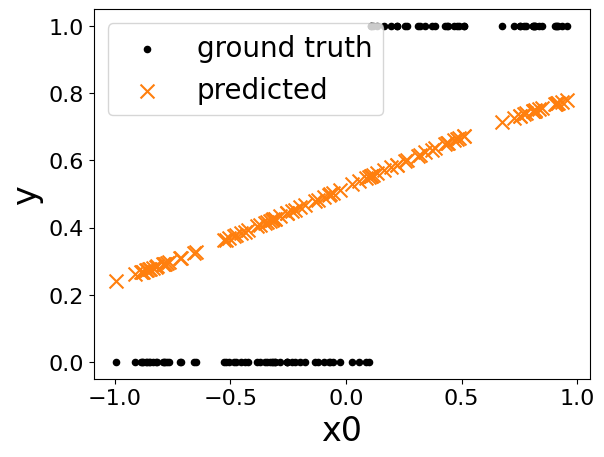

In [20]:
from plotting import plot_pred_1d

plot_pred_1d(x, y_gt, y_p=neuron_1d(w0,b, x))

c) Next, define the functions needed to optimize the weight and bias. The task of the
optimization process is to minimize the error function. 

In [21]:
def d_loss_d_ypred(y_pred, y_true):
    """∂ε/∂y_pred = 2(y_pred - y_true)"""
    return 2 * (y_pred - y_true)

def d_ypred_d_param(y_pred, x):
    """
    ∂y_pred/∂w = sigmoid'(z) * x
    ∂y_pred/∂b = sigmoid'(z) * 1
    sigmoid'(z) = sigmoid(z) * (1 - sigmoid(z)) = y_pred * (1 - y_pred)
    """
    sigmoid_prime = y_pred * (1 - y_pred)
    dw = sigmoid_prime * x   # ∂y_pred/∂w
    db = sigmoid_prime        # ∂y_pred/∂b  (x=1 for bias)
    return dw, db

d) Finally, implement the training loop, in which the parameters are updated.
Implement it in the following way. Set the learning rate parameter to 0.01. For
each iteration, pick one data point from the data at random. Evaluate the
prediction by the neuron on this data point, and store the error. Update the
parameters using the functions defined in c. Iterate this for 100 000 iterations,
and make a plot of the predictions made by the neuron after training. Did it
improve? Also, plot the prediction error made by the neuron as a function of the
iteration count. Does it decrease?

It did improve a little bit but no

In [22]:
num_samples = len(x)
num_train_iterations = 100000
eta = 0.01
errors = []

for i in range(num_train_iterations):
    selected = rng.integers(0, num_samples)
    x0_selected = x[selected]
    y_gt_selected = y_gt[selected]

    y_p_selected = neuron_1d(w0, b, x0_selected)

    dloss  = d_loss_d_ypred(y_p_selected, y_gt_selected)
    dw, db = d_ypred_d_param(y_p_selected, x0_selected)

    w0 = w0 - eta * dloss * dw
    b  = b  - eta * dloss * db

    errors.append(squared_error(y_p_selected, y_gt_selected))


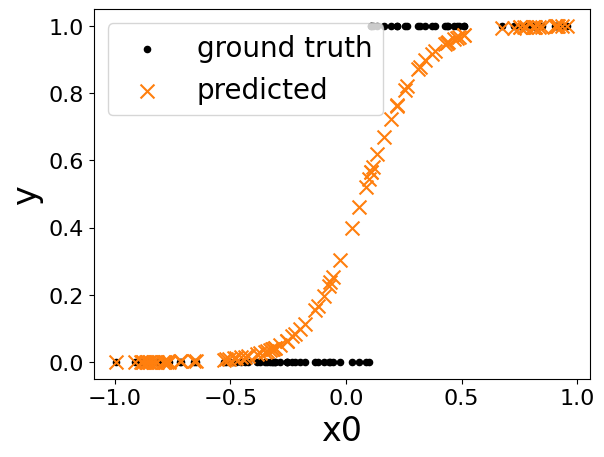

In [23]:
plot_pred_1d(x, y_gt, y_p=neuron_1d(w0, b, x))

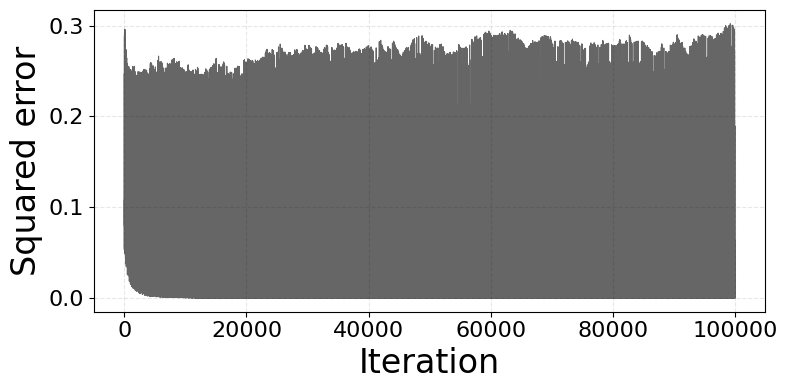

In [24]:
from plotting import plot_error

plot_error(errors)

e) Part of the problem with the training in d is that the updates are made on
individual data points, making the prediction errors fluctuate wildly. To counter
this, neural networks are typically trained using batch-wise learning, in which the
parameters are not updated after every step. Implement this in the following way.
For each iteration in the training loop, pick at random N data points from the data
set. The number N is commonly referred to as the batch size. Calculate the errors
and the gradients for each data point in the batch, and then update the
parameters using the average gradient across the batch. Store also the average
error over each batch. Iterate over 10 000 batches, and plot the evolution of the
batch-wise error as well as the prediction by the trained neuron, experimenting
with a few diderent values of N and 𝜂. Hint: In general, you can use higher values
of the learning rate for larger batches

In [25]:
num_train_iterations = 10000
batch_size = 32
eta = 0.5
errors = []

for i in range(num_train_iterations):
    batch = rng.integers(0, num_samples, size=batch_size)
    x_batch    = x[batch]
    y_gt_batch = y_gt[batch]

    y_p_batch = neuron_1d(w0, b, x_batch)

    dloss        = d_loss_d_ypred(y_p_batch, y_gt_batch)
    dw, db       = d_ypred_d_param(y_p_batch, x_batch)

    w0 = w0 - eta * np.mean(dloss * dw)
    b  = b  - eta * np.mean(dloss * db)

    errors.append(np.mean(squared_error(y_p_batch, y_gt_batch)))


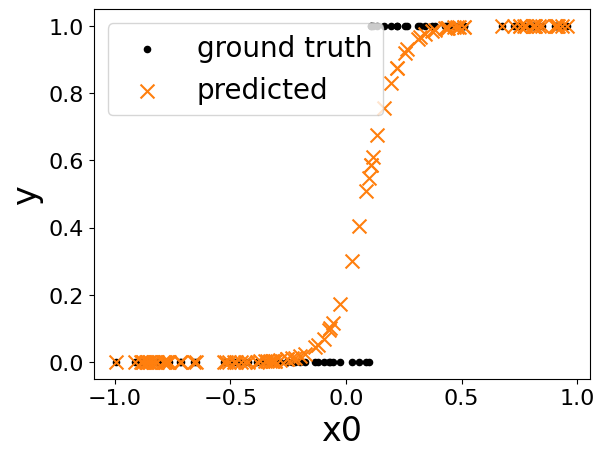

In [26]:
plot_pred_1d(x, y_gt, y_p=neuron_1d(w0, b, x))

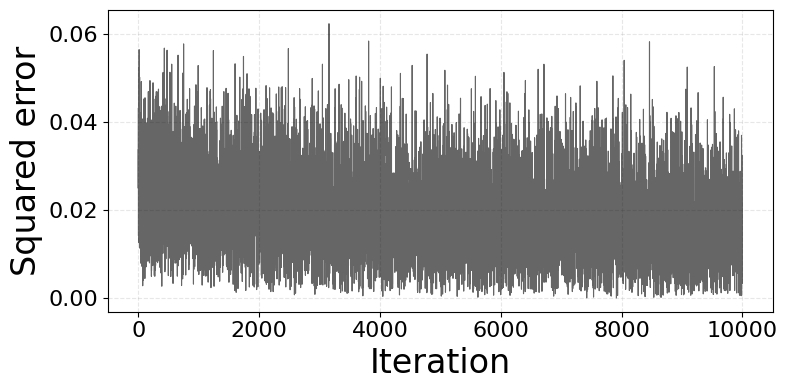

In [27]:
plot_error(errors)